# PROGRAMMING EXERCISE: SURVIVING ON THE TITANIC

<font size="3">In our programming exercise today, we will focus on a historical classification problem. On April 14, 1912, the Titanic, at the time the largest passenger ship in the world, collided with an iceberg and sank. The majority of the passengers did not survive the tragedy. But what distinguishes passengers who survived from those who went down with the ship? Today, we want to develop a model that predicts the survival of Titanic passengers based on various personal characteristics. Let’s get started!</font>

In [1]:
# Note: It is not good practice to ignore all warnings, but I put it here to avoid confusion,
# if warnings that do not break the code occur.
import warnings
warnings.filterwarnings("ignore")

## 1 // LOAD THE DATA

<font size="3">**Task 1**:\
Download the data file titanic.csv from GitHub and save it in a location of your choice. Read the file into a pandas DataFrame in Python.</font>

In [2]:
import pandas as pd

titanic = pd.read_csv('titanic.csv')

## 2 // DATA EXPLORATION & CLEANING

<font size="3">**Task 2**:\
Get an overview of the data. Answer the following questions:</font>

* <font size="3">How many data points are in our dataset?</font>
* <font size="3">What are the names of the variables (columns) in our dataset and what do they mean?</font>
* <font size="3">Which variables contain how many missing values?</font>
* <font size="3">What data types do our variables have? Do the data types make sense?</font>


<font size="3">For more information about the dataset, visit: [https://www.kaggle.com/c/titanic/data](https://www.kaggle.com/c/titanic/data)</font>

In [3]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(f'Number of data points in the dataset: {len(titanic)}')
print(f'\nVariable names: {list(titanic.columns)}')
print(f'\nMissing values:')
print(titanic.isnull().sum())
print(f'\nData types:')
print(titanic.dtypes)

Number of data points in the dataset: 891

Variable names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


<font size="3">**Task 3**:\
Create a bar chart that describes the distribution of survivors and non-survivors. Give it a title and label the axes.</font>

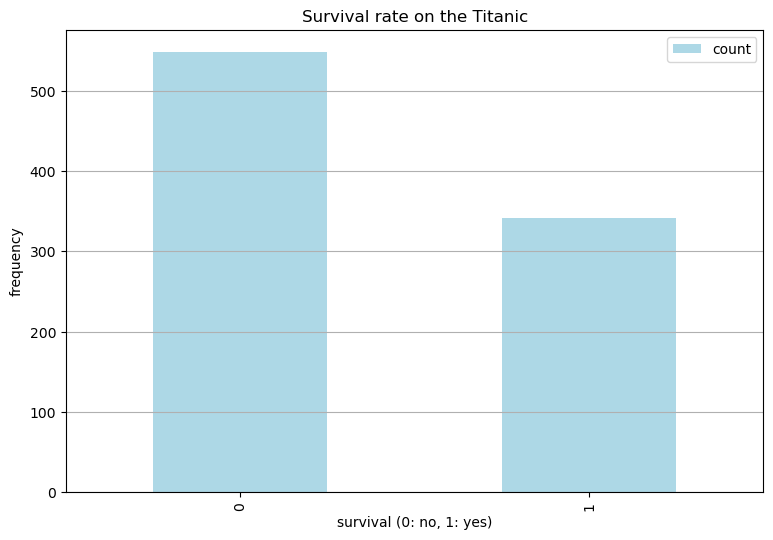

In [5]:
import matplotlib.pyplot as plt

survived = pd.DataFrame(titanic.Survived.value_counts()).reset_index()
survived.plot.bar(x='Survived', y='count', color='lightblue', figsize=(9, 6))
plt.grid(axis='y')
plt.title("Survival rate on the Titanic")
plt.xlabel("survival (0: no, 1: yes)")
plt.ylabel("frequency")
plt.show()

<font size="3">**Task 4**:\
Get an overview of the relationships between features (independent variables) and the variable to be predicted ("Survived"). To do this, create the following plots:</font>

* <font size="3">a bar chart showing the variable "Survived" separated by gender</font>
* <font size="3">a bar chart showing the variable "Survived" separated by ticket classes</font>
* <font size="3">two histograms showing the age distribution of people who survived and did not survive</font>
* <font size="3">a bar chart showing the variable "Survived" separated by port of embarkation</font>

<font size="3">As always, give your plots a title and label the axes.</font>

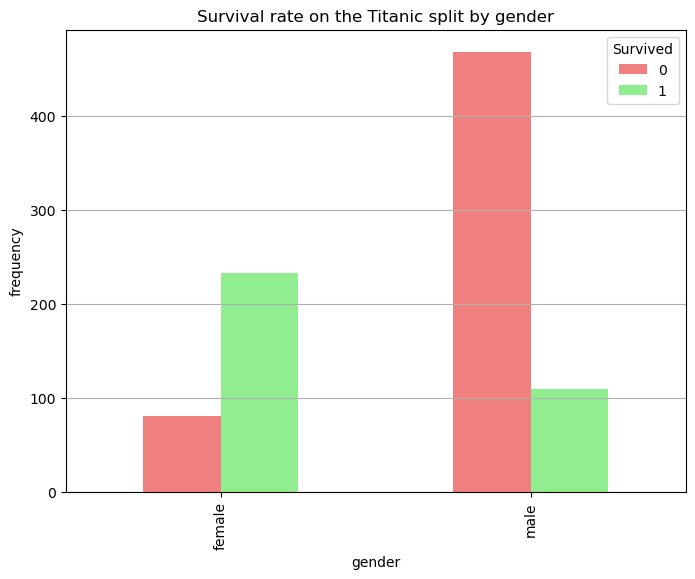

In [6]:
pd.crosstab(titanic['Sex'],titanic['Survived']).plot(kind="bar", figsize=(8,6), color=['lightcoral', 'lightgreen'])
plt.grid(axis='y')
plt.title("Survival rate on the Titanic split by gender")
plt.xlabel("gender")
plt.ylabel("frequency")
plt.show()

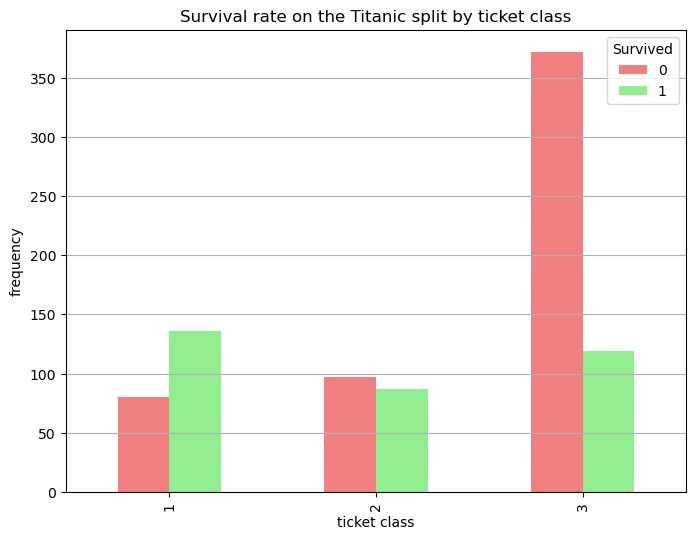

In [7]:
pd.crosstab(titanic['Pclass'],titanic['Survived']).plot(kind="bar", figsize=(8,6), color=['lightcoral', 'lightgreen'])
plt.grid(axis='y')
plt.title("Survival rate on the Titanic split by ticket class")
plt.xlabel("ticket class")
plt.ylabel("frequency")
plt.show()

Text(0.5, 0, 'age')

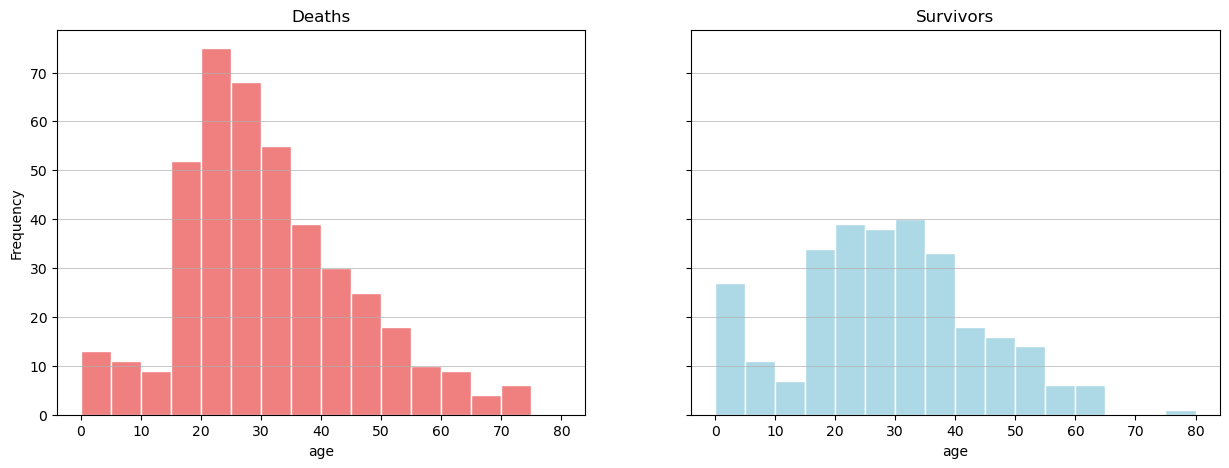

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
titanic[titanic['Survived']==0]['Age'].plot.hist(ax=ax[0], bins=list(range(0, 81, 5)),
                                                 edgecolor='white', color='lightcoral')
titanic[titanic['Survived']==1]['Age'].plot.hist(ax=ax[1], bins=list(range(0, 81, 5)),
                                                 edgecolor='white', color='lightblue')
ax[0].grid(axis='y', linewidth=0.5)
ax[1].grid(axis='y', linewidth=0.5)
ax[0].set_title('Deaths')
ax[1].set_title('Survivors')
ax[0].set_xlabel('age')
ax[1].set_xlabel('age')

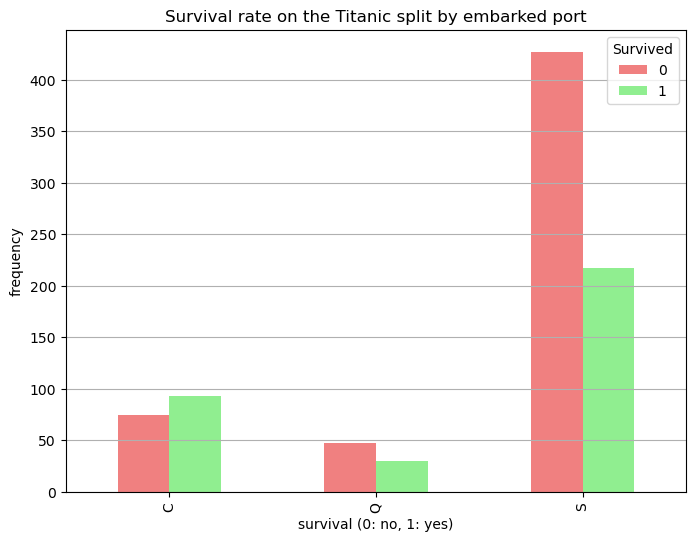

In [9]:
pd.crosstab(titanic['Embarked'], titanic['Survived']).plot(kind="bar", figsize=(8,6), color=['lightcoral', 'lightgreen'])
plt.grid(axis='y')
plt.title("Survival rate on the Titanic split by embarked port")
plt.xlabel("survival (0: no, 1: yes)")
plt.ylabel("frequency")
plt.show()

### MISSING VALUE IMPUTATION

<font size="3">**Task 5:**\
Our feature Age has a lot of missing values. We can try to impute the missing values. One option would be to simply use the mean. A better idea could be to isolate the title from the passengers’ names, calculate a separate mean for each title class, and then use this mean to fill in the missing values according to the title. Perform the following steps:</font>

* <font size="3">Create a new column in the DataFrame called 'Initial'.</font>
* <font size="3">For each data point, search the name and extract the title using a regular expression.<sup>1</sup></font>
* <font size="3">Store the extracted title in the new column 'Initial'.</font>
* <font size="3">Examine which titles are represented in the new column 'Initial'.</font>
* <font size="3">All titles except Mr, Miss, Mrs & Master are not of interest to us. Replace these titles with "other".</font>
* <font size="3">Calculate the mean ages for each title class. Round the results.</font>
* <font size="3">Replace missing values in the Age column with the calculated means.</font>

<font size="3"><sup>1</sup> Note: You can use the pandas function Series.str.extract(). An appropriate regular expression is '([A-Za-z]+).'. The regular expression finds all strings in the name followed by a period. Pass the regular expression as a parameter to the function.</font>


In [10]:
titanic['Initial'] = titanic.Name.str.extract('([A-Za-z]+)\.')

In [11]:
titanic.Initial.value_counts()

Initial
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [12]:
new_initials = []

for passenger in range(len(titanic)):
    if titanic['Initial'].iloc[passenger] not in ['Mr', 'Miss', 'Mrs', 'Master']:
        new_initials.append('other')
    else:
        new_initials.append(titanic['Initial'].iloc[passenger])

titanic['Initial'] = new_initials

In [13]:
titanic.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.773973
Mr        32.368090
Mrs       35.898148
other     42.384615
Name: Age, dtype: float64

In [14]:
for initial, age in zip(['Mr', 'Miss', 'Mrs', 'Master', 'other'], [33, 22, 36, 5, 43]):
    titanic.loc[(titanic.Age.isnull()) & (titanic.Initial==initial), 'Age'] = age

### FEATURE ENGINEERING

<font size="3">**Task 6:**\
We want to transform some of the features. In particular, classification algorithms can struggle with numerical independent variables.</font>

* <font size="3">Create a new binary feature 'Alone' from the features 'SibSp' and 'Parch', which indicates whether a person traveled alone or with family members. (Which values must 'SibSp' and 'Parch' have for 'Alone' to apply?)</font>
* <font size="3">Create a plot showing the survival rate of solo travelers vs. travelers with family.<sup>2</sup></font>
* <font size="3">Transform Age into a new categorical variable 'Age_cat' with the classes 0-10, 11-20, 21-30, 31-40, 41-50, 51-60, 61-70, 70+.</font>
* <font size="3">Transform the ticket cost ('Fare') into a new categorical variable 'Fare_cat' with 5 equally sized bins.<sup>3</sup></font>

<font size="3"><sup>2</sup> Note: Look at the seaborn package using the function catplot.\
<sup>3</sup> Note: You can use the pandas function qcut.</font>

In [15]:
alone = []
for passenger in range(len(titanic)):
    if titanic['SibSp'].iloc[passenger] == 0 and titanic['Parch'].iloc[passenger] == 0:
        alone.append(1)
    else:
        alone.append(0)
titanic['Alone'] = alone

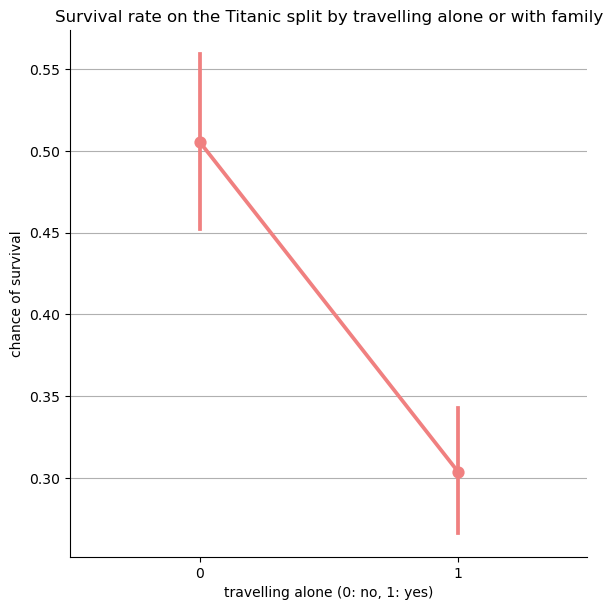

In [16]:
import seaborn as sns

sns.catplot(x='Alone',y='Survived',data=titanic, kind='point', height=6, color='lightcoral')
plt.grid(axis='y')
plt.title("Survival rate on the Titanic split by travelling alone or with family")
plt.xlabel("travelling alone (0: no, 1: yes)")
plt.ylabel("chance of survival")
plt.show()

In [17]:
import numpy as np

age_cat = []
for passenger in range(len(titanic)):
    if titanic.Age.iloc[passenger] <= 10:
        age_cat.append(0)
    elif titanic.Age.iloc[passenger] > 10 and titanic.Age.iloc[passenger] <= 20:
        age_cat.append(1)
    elif titanic.Age.iloc[passenger] > 20 and titanic.Age.iloc[passenger] <= 30:
        age_cat.append(2)
    elif titanic.Age.iloc[passenger] > 30 and titanic.Age.iloc[passenger] <= 40:
        age_cat.append(3)
    elif titanic.Age.iloc[passenger] > 40 and titanic.Age.iloc[passenger] <= 50:
        age_cat.append(4)
    elif titanic.Age.iloc[passenger] > 50 and titanic.Age.iloc[passenger] <= 60:
        age_cat.append(5)
    elif titanic.Age.iloc[passenger] > 60 and titanic.Age.iloc[passenger] <= 70:
        age_cat.append(6)
    elif titanic.Age.iloc[passenger] > 70:
        age_cat.append(7)
    else:
        age_cat.append(np.nan)

titanic['Age_cat'] = age_cat

In [18]:
titanic['Fare_qcut']=pd.qcut(titanic['Fare'], 5)
titanic.Fare_qcut.value_counts()

Fare_qcut
(7.854, 10.5]        184
(21.679, 39.688]     180
(-0.001, 7.854]      179
(39.688, 512.329]    176
(10.5, 21.679]       172
Name: count, dtype: int64

In [19]:
titanic['Fare_cat'] = 0

titanic.loc[titanic['Fare'] <= 7.9, 'Fare_cat'] = 0
titanic.loc[(titanic['Fare'] > 7.9) & (titanic['Fare'] <= 10.5), 'Fare_cat'] = 1
titanic.loc[(titanic['Fare'] > 10.5) & (titanic['Fare'] <= 21.7), 'Fare_cat'] = 2
titanic.loc[(titanic['Fare'] > 21.7) & (titanic['Fare'] <= 39.7), 'Fare_cat'] = 3
titanic.loc[(titanic['Fare'] > 39.7), 'Fare_cat'] = 4

<font size="3">**Task 7:**\
So that our algorithm can later process our categorical variables, we will convert the string-encoded variables into numerical variables: Transform 'Sex', 'Embarked', and 'Initial' so that the categories are represented by numbers.</font>

<font size="3">Note: Use the pandas function replace.</font>

In [20]:
titanic['Sex'] = titanic['Sex'].replace(['male', 'female'], [0, 1])
titanic['Embarked'] = titanic['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2])
titanic['Initial'] = titanic['Initial'].replace(['Mr', 'Mrs', 'Miss', 'Master', 'other'], [0, 1, 2, 3, 4])

In [21]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Alone,Age_cat,Fare_qcut,Fare_cat
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,0,0,2,"(-0.001, 7.854]",0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,1,0,3,"(39.688, 512.329]",4
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,2,1,2,"(7.854, 10.5]",1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,1,0,3,"(39.688, 512.329]",4
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,0,1,3,"(7.854, 10.5]",1


In [22]:
titanic.Initial.value_counts()

Initial
0    517
2    182
1    125
3     40
4     27
Name: count, dtype: int64

<font size="3">**Task 8:**\
Before we start model fitting, we will remove features that we created solely as helper features or that cannot be processed by our algorithm later: Exclude the features 'PassengerId', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Fare_qcut' from the DataFrame.</font>

In [23]:
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Fare_qcut'])

<font size="3">Also, run the following cell to exclude the two rows with NaN values in 'Embarked'. (Otherwise, the logistic regression or the random forest classifier will throw an error.)</font>

In [24]:
titanic = titanic.dropna()

### DATA PREPARATION: TRAIN-TEST SPLIT

<font size="3">**Task 9:**\
Split the dataset into train (60%), validation (20%), and test (20%) sets. To do this, use the sklearn function train_test_split twice: First, split into train and test in an 80 to 20 ratio. Then, split the resulting train set again into train and validation in a 75 to 25 ratio. Set the random_state parameter to make the result reproducible.</font>

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(titanic.drop(columns=['Survived']), titanic.Survived,
                                                    test_size=0.2, random_state=15)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=15)

In [26]:
X_train

,Pclass,Sex,Embarked,Initial,Alone,Age_cat,Fare_cat
432,2,1,0,1,0,4,3
843,3,0,1,0,1,3,0
655,2,0,0,0,0,2,4
365,3,0,0,0,1,2,0
174,1,0,1,0,1,5,3
...,...,...,...,...,...,...,...
862,1,1,0,1,1,4,3
873,3,0,0,0,1,4,1
254,3,1,0,1,0,4,2
643,3,0,0,0,1,3,4


<font size="3" color="purple">**Task 9 (advanced/optional):**\
Instead of only splitting the data into training, validation, and test set once, let's split the data into a held-out test set and the remaining data into another five folds for 5-fold cross-validation. We can store the files with the held-out test set and the folds into csvs for later use. To achieve this, do the following:</font>

<font size="3" color="purple">1. Create a folder to store the files.</font>\
<font size="3" color="purple">2. First, split 20% from the data as held-out test set and store to files.</font>\
<font size="3" color="purple">3. Now, for the remainder of the data (80%), use scikit-learns KFold to get five data splits.</font>\
<font size="3" color="purple">4. Iterate over each of the splits and store them to files.</font>

In [31]:
import os
from sklearn.model_selection import KFold

# create folder for to store data splits
if not os.path.exists("data-splits"):
    os.makedirs("data-splits")

# create 20% test split
X_temp, X_test, y_temp, y_test = train_test_split(titanic.drop(columns=['Survived']), titanic.Survived,
                                                  test_size=0.2, random_state=15)

# save held-out test set to file
X_test.to_csv("data-splits/X_test.csv", index=False)
y_test.to_csv("data-splits/y_test.csv", index=False)

# from the remaining 80% of the data: create five folds of train-validation split
kf = KFold(n_splits=5, shuffle=True, random_state=15)

for i, (train_idx, val_idx) in enumerate(kf.split(X_temp)):

    X_train = X_temp.iloc[train_idx]
    y_train = y_temp.iloc[train_idx]

    X_val = X_temp.iloc[val_idx]
    y_val = y_temp.iloc[val_idx]

    # save to files
    X_train.to_csv(f"data-splits/X_train_{i+1}.csv", index=False)
    y_train.to_csv(f"data-splits/y_train_{i+1}.csv", index=False)

    X_val.to_csv(f"data-splits/X_val_{i+1}.csv", index=False)
    y_val.to_csv(f"data-splits/y_val_{i+1}.csv", index=False)

## 3 + 4 // MODEL SELECTION & EVALUATION

<font size="3">**Task 10:**\
Fit a logistic regression to the data. We want to compare this later with a random forest classifier. Evaluate the model’s performance on the test set in terms of accuracy. Create a plot showing the confusion matrix. Does the model predict more false positives or false negatives?</font>

<font size="3">Note: You can use the class LogisticRegression from sklearn. You don’t need to set any parameters when initializing the model. Sklearn also provides the functions accuracy_score and confusion_matrix in the metrics module.</font>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
pred = log_reg.predict(X_test)
print('The accuracy of the Logistic Regression is', accuracy_score(pred, y_test))

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='2.0f')
plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Predicted label')
plt.ylabel('True label')

<font size="3">**Task 11:**\
Fit a Random Forest Classifier (without parameters) to the data and evaluate its accuracy score on the test set.</font>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier()
forest.fit(X_train, y_train)
pred = forest.predict(X_test)
print('The accuracy of the Random Forest Classifier is', accuracy_score(pred, y_test))

## 5 + 6 // FINE TUNING & PREDICTION

<font size="3">**Task 12:**\
Tune the hyperparameters of your Random Forest using a (full) grid search (i.e., try each possible parameter combination). Use the given parameter grid. (Or try creating your own?)</font>

In [54]:
from sklearn.model_selection import GridSearchCV

n_estimators = list(range(100, 1001, 100))
max_features = [0.5, 'auto', 'sqrt', 'log2']
min_samples_leaf = list(range(2, 21, 2))
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'min_samples_leaf': min_samples_leaf}
print(param_grid)

forest = RandomForestClassifier()

grid_search = GridSearchCV(estimator=forest,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           verbose=2,
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000], 'max_features': [0.5, 'auto', 'sqrt', 'log2'], 'min_samples_leaf': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]}


NameError: name 'RandomForestClassifier' is not defined

<font size="3">Retrieve the best parameters for the Random Forest Classifier returned by your Grid Search. Also, calculate the accuracy for the best model from the Grid Search.</font>

<font size="3">Note: Sklearn’s GridSearchCV class stores the best model. It can be accessed via the attribute best_estimator_.</font>

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_estimator_.score(X_test, y_test))

<font size="3">Create a confusion matrix for the Random Forest Classifier. Does the Random Forest predict more false positives or false negatives? How does its performance compare to the logistic regression?</font>

In [ ]:
sns.heatmap(confusion_matrix(y_test, grid_search.best_estimator_.predict(X_test)), annot=True, fmt='2.0f')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted label')
plt.ylabel('True label')

<font size="3" color="purple">**Task 12 (advanced/optional):**\
Let's refine our training approach further by combining a few techniques that we've learned. First, we would like to use a more powerful random forest classifier called xgboost. Second, we would like to perform a random grid search (instead of a full one). Third, we will perform the hyperparameter tuning (grid search) on each of the five data folds from earlier, store the best parameter combinations, and determine the final model based on the held-out test set.</font>

<font size="3" color="purple">To achieve this, do the following:</font>

<font size="3" color="purple">1. From scikit-learn import ParameterSampler, f1_score; and from xgboost import XGBClassifier.</font>\
<font size="3" color="purple">2. Define the parameter grid as a dictionary. Specify value ranges for parameters n_estimators, max_depth, learning_rate, and gamma. [[What do those parameters mean?](https://xgboost.readthedocs.io/en/latest/python/python_api.html)]</font>\
<font size="3" color="purple">3. Sample five combinations from that parameter space using the ParameterSampler.</font>\
<font size="3" color="purple">4. Create a loop with five iterations. In each iteration, load the respective data fold (train and validation). Then inside the loop, create another loop, where - for the current split - you try out each of the parameter combinations sampled in the previous step. Therefore, instantiate the model, fit it, and predict on the validation set using the f1_score. Write the code in a way that after each iteration over one of the folds is finished, you store the best validation F1 score and the best parameter combinations for that fold in a variable.</font>

<font size="3" color="purple">Finally, load the held-out test set. Recreate the best model with the saved parameter combinations for each of the splits. Predict the F1 score on the test set. For each fold, compare the validation and test F1 score. Which is the best model according to the held-out test set?</font>

In [33]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

In [34]:
# define the parameter space
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "gamma": [0, 0.1, 0.3]
}

In [36]:
# sample "n_iter" random combinations from the parameter space
param_list = list(ParameterSampler(param_grid, n_iter=5, random_state=15))

# let's look at the sampled parameters
for param_comb in param_list:
    print(param_comb)

{'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0}
{'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3}
{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1}
{'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0}
{'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0}


In [41]:
results = {}

# iterate over our five folds to perform hyperparameter tuning with the above parameters on each of them
for fold in range(1, 6):

    print(f"--- RUNNING FOLD {fold} ---")

    # load the data splits previously computed and stored
    X_train = pd.read_csv(f"data-splits/X_train_{fold}.csv")
    y_train = pd.read_csv(f"data-splits/y_train_{fold}.csv")

    X_val = pd.read_csv(f"data-splits/X_val_{fold}.csv")
    y_val = pd.read_csv(f"data-splits/y_val_{fold}.csv")

    best_score = -1
    best_params = None

    # iterate over all parameter combinations in param_list for current fold
    for params in param_list:

        # instantiate model
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=15,
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            gamma=params["gamma"]
        )

        model.fit(X_train, y_train)  #fit

        preds = model.predict(X_val)  # predict

        score = f1_score(y_val, preds)  # score

        # if the current model is better than the previous ones,
        # store f1 on validation set and parameters
        if score > best_score:
            best_score = score
            best_params = params

    # collect best score and parameters for each of the five folds in overall results variable
    results[fold] = (best_score, best_params)

print("--- DONE! ---")

--- RUNNING FOLD 1 ---
--- RUNNING FOLD 2 ---
--- RUNNING FOLD 3 ---
--- RUNNING FOLD 4 ---
--- RUNNING FOLD 5 ---
--- DONE! ---
{1: (0.693069306930693, {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1}), 2: (0.7058823529411765, {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3}), 3: (0.7272727272727273, {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0}), 4: (0.7722772277227723, {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1}), 5: (0.7843137254901961, {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3})}


In [53]:
# instantiate dataframe to test models on held-out test set
compare_models = pd.DataFrame(columns=["fold", "validation score", "test score"])

# load held-out test data
X_test = pd.read_csv(f"data-splits/X_test.csv")
y_test = pd.read_csv(f"data-splits/y_test.csv")

# iterate over all models in results and compute performance on test set
for i in results.keys():
    ps = results[i][1]

    model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=15,
            n_estimators=ps["n_estimators"],
            max_depth=ps["max_depth"],
            learning_rate=ps["learning_rate"],
            gamma=ps["gamma"]
        )

    model.fit(X_train, y_train)

    test_preds = model.predict(X_test)
    test_f1 = f1_score(y_test, test_preds)

    # store results in dataframe
    compare_models.loc[i-1] = [, results[i][0], test_f1]

compare_models

,fold,validation score,test score
0,1.0,0.693069,0.720721
1,2.0,0.705882,0.782609
2,3.0,0.727273,0.758621
3,4.0,0.772277,0.720721
4,5.0,0.784314,0.782609


### Congratulations! :)

<font size="3">If you’ve made it this far, you have loaded a dataset, analyzed and cleaned it, created plots, performed feature engineering, conducted a train-test split, fitted two different models, and compared them. Way to go!</font>

<font size="3">For further information, analyses, and models on the Titanic dataset, I recommend:
[https://www.kaggle.com/ash316/eda-to-prediction-dietanic](https://www.kaggle.com/ash316/eda-to-prediction-dietanic)</font>